In [1]:
import pandas as pd
import numpy as np

# Load and prepare data

In [2]:
fields = pd.read_csv("outputs/2.0-discovery_results.csv")
canonical = pd.read_csv(
    "outputs/4.2-final_labeled_field_profiles.csv",
    usecols=["metadata_field", "canonical_name", "confidence"],
)

In [3]:
df = fields.merge(canonical, on="metadata_field", how="left")
df["confidence"] = df["confidence"].map({"high": 3, "medium": 2, "low": 1})
df

,snapshot_id,snapshot_type,source,model,metadata_field,observed_value,description,source_level,discovery_value,reasoning,canonical_name,confidence
0,027_Jordan-Emergency-Food-Security-Project_fig...,figure,refugee,gpt-5.5,figure_title,Figure 2: Share of food expenditure in total e...,The title or caption identifying the figure an...,snapshot,high,The figure title provides the most direct sear...,title,3
1,027_Jordan-Emergency-Food-Security-Project_fig...,figure,refugee,gpt-5.5,indicator_name,Share of food expenditure in total expenditure...,The main measure or indicator represented in t...,snapshot,high,Indicator-level metadata enables retrieval of ...,indicator_name,3
2,027_Jordan-Emergency-Food-Security-Project_fig...,figure,refugee,gpt-5.5,subject_domain,Food expenditure; food security,The thematic domain or topical area represente...,both,high,The figure title and document metadata both co...,subject_domain,3
3,027_Jordan-Emergency-Food-Security-Project_fig...,figure,refugee,gpt-5.5,geographic_scope,"Jordan, inferred from parent document title an...","The country, region, or geographic area to whi...",document,high,Geographic context is essential for discovery ...,geographic_scope,3
4,027_Jordan-Emergency-Food-Security-Project_fig...,figure,refugee,gpt-5.5,time_period,Not identifiable from this snapshot,"The date, year, or period covered by the data ...",snapshot,high,A data time period would be highly useful for ...,time_period,3
...,...,...,...,...,...,...,...,...,...,...,...,...
3036,document_10395051_table_002.png,table,prwp,gpt-5.5,significance_notation,"*, ** and *** denote significance at the 10 pe...",Notation used to indicate statistical signific...,snapshot,medium,Significance notation is needed to interpret c...,interpretive_note,3
3037,document_10395051_table_002.png,table,prwp,gpt-5.5,robustness_adjustment,Heteroskedasticity-robust t(z)-statistics are ...,Adjustments or corrections applied to reported...,snapshot,medium,Inference adjustments improve reuse by indicat...,analysis_method,2
3038,document_10395051_table_002.png,table,prwp,gpt-5.5,endogenous_variable,Each of four informality measures,Variables treated as endogenous in instrumenta...,snapshot,medium,Endogeneity treatment is important for underst...,indicator_name,2
3039,document_10395051_table_002.png,table,prwp,gpt-5.5,instrumental_variables,Law and order; Business regulatory freedom; Av...,Instruments used in instrumental-variable regr...,snapshot,high,Instrumental variables are key metadata for di...,not_in_ontology,3


In [4]:
df[df["canonical_name"].isna()]

,snapshot_id,snapshot_type,source,model,metadata_field,observed_value,description,source_level,discovery_value,reasoning,canonical_name,confidence


# Frequency analysis

## Canonical field support

In [5]:
snapshot_count = df["snapshot_id"].nunique()
df["figure_snapshot_id"] = np.where(
    df["snapshot_type"] == "figure", df["snapshot_id"], None
)
df["table_snapshot_id"] = np.where(
    df["snapshot_type"] == "table", df["snapshot_id"], None
)

agg1 = df.groupby("canonical_name").agg(
    snapshot_count=("snapshot_id", "nunique"),
    snapshot_support=("snapshot_id", lambda x: x.nunique() / snapshot_count),
    corpora_count=("source", "nunique"),
    figure_count=("figure_snapshot_id", "nunique"),
    table_count=("table_snapshot_id", "nunique"),
    avg_confidence=("confidence", "mean"),
)

agg1

,snapshot_count,snapshot_support,corpora_count,figure_count,table_count,avg_confidence
canonical_name,,,,,,
analysis_method,41,0.195238,3,14,27,2.754098
calculation_method,26,0.123810,3,6,20,2.571429
category_dimension,91,0.433333,3,59,32,2.424779
category_labels,109,0.519048,3,62,47,2.863636
column_dimension,93,0.442857,3,14,79,2.989362
comparison_group,26,0.123810,3,16,10,2.724138
currency,26,0.123810,3,6,20,3.000000
data_collection_method,9,0.042857,3,4,5,3.000000
data_source,98,0.466667,3,65,33,2.982301


## By corpus

In [6]:
df["unhcr_snapshot_id"] = np.where(df["source"] == "unhcr", df["snapshot_id"], None)
df["prwp_snapshot_id"] = np.where(df["source"] == "prwp", df["snapshot_id"], None)
df["refugee_snapshot_id"] = np.where(df["source"] == "refugee", df["snapshot_id"], None)

agg2 = df.groupby("canonical_name").agg(
    snapshot_count=("snapshot_id", "nunique"),
    unhcr_count=("unhcr_snapshot_id", "nunique"),
    prwp_count=("prwp_snapshot_id", "nunique"),
    refugee_count=("refugee_snapshot_id", "nunique"),
)

agg2

,snapshot_count,unhcr_count,prwp_count,refugee_count
canonical_name,,,,
analysis_method,41,1,39,1
calculation_method,26,8,15,3
category_dimension,91,31,37,23
category_labels,109,45,26,38
column_dimension,93,24,26,43
comparison_group,26,6,10,10
currency,26,5,2,19
data_collection_method,9,6,1,2
data_source,98,38,36,24


## By snapshot type

In [7]:
agg3 = df.groupby("canonical_name").agg(
    snapshot_count=("snapshot_id", "nunique"),
    figure_count=("figure_snapshot_id", "nunique"),
    table_count=("table_snapshot_id", "nunique"),
)

agg3

,snapshot_count,figure_count,table_count
canonical_name,,,
analysis_method,41,14,27
calculation_method,26,6,20
category_dimension,91,59,32
category_labels,109,62,47
column_dimension,93,14,79
comparison_group,26,16,10
currency,26,6,20
data_collection_method,9,4,5
data_source,98,65,33


## By source level

In [8]:
df["snapshot_snapshot_id"] = np.where(
    df["source_level"] == "snapshot", df["snapshot_id"], None
)
df["document_snapshot_id"] = np.where(
    df["source_level"] == "document", df["snapshot_id"], None
)
df["both_snapshot_id"] = np.where(df["source_level"] == "both", df["snapshot_id"], None)


agg4 = df.groupby("canonical_name").agg(
    snapshot_count=("snapshot_id", "nunique"),
    source_snapshot_count=("snapshot_snapshot_id", "nunique"),
    source_document_count=("document_snapshot_id", "nunique"),
    source_both_count=("both_snapshot_id", "nunique"),
)

agg4

,snapshot_count,source_snapshot_count,source_document_count,source_both_count
canonical_name,,,,
analysis_method,41,36,5,3
calculation_method,26,26,0,0
category_dimension,91,87,1,4
category_labels,109,109,0,0
column_dimension,93,93,0,0
comparison_group,26,26,0,0
currency,26,26,0,0
data_collection_method,9,8,1,0
data_source,98,91,2,6


## Diversity

In [9]:
agg5 = df.groupby("canonical_name").agg(
    snapshot_count=("snapshot_id", "nunique"),
    n_unique_observed_values=("observed_value", "nunique"),
)

agg5

,snapshot_count,n_unique_observed_values
canonical_name,,
analysis_method,41,58
calculation_method,26,28
category_dimension,91,105
category_labels,109,131
column_dimension,93,88
comparison_group,26,28
currency,26,15
data_collection_method,9,10
data_source,98,73


## Alias richness

In [10]:
agg6 = df.groupby("canonical_name").agg(
    snapshot_count=("snapshot_id", "nunique"),
    snapshot_support=("snapshot_id", lambda x: x.nunique() / snapshot_count),
    alias_count=("metadata_field", "nunique"),
)

agg6

,snapshot_count,snapshot_support,alias_count
canonical_name,,,
analysis_method,41,0.195238,27
calculation_method,26,0.123810,16
category_dimension,91,0.433333,60
category_labels,109,0.519048,51
column_dimension,93,0.442857,5
comparison_group,26,0.123810,13
currency,26,0.123810,4
data_collection_method,9,0.042857,6
data_source,98,0.466667,14


## Support scoring

In [11]:
# support_score = (snapshot_support) x (corpora_count / 3) × (avg_confidence / 3)

agg1["support_score"] = (
    agg1["snapshot_support"] * agg1["corpora_count"] / 3 * agg1["avg_confidence"] / 3
)

agg1.sort_values("support_score", ascending=False)

,snapshot_count,snapshot_support,corpora_count,figure_count,table_count,avg_confidence,support_score
canonical_name,,,,,,,
title,195,0.928571,3,101,94,2.995025,0.927032
geographic_scope,194,0.923810,3,96,98,2.995050,0.922285
indicator_name,194,0.923810,3,99,95,2.845361,0.876190
unit_of_measure,185,0.880952,3,101,84,2.954082,0.867468
time_period,156,0.742857,3,87,69,2.957831,0.732415
not_in_ontology,149,0.709524,3,70,79,2.424107,0.573321
subject_domain,121,0.576190,3,69,52,2.913043,0.559489
row_dimension,105,0.500000,3,16,89,2.973451,0.495575
category_labels,109,0.519048,3,62,47,2.863636,0.495455


## Alias count vs Snapshot support 

In [12]:
import plotly.express as px

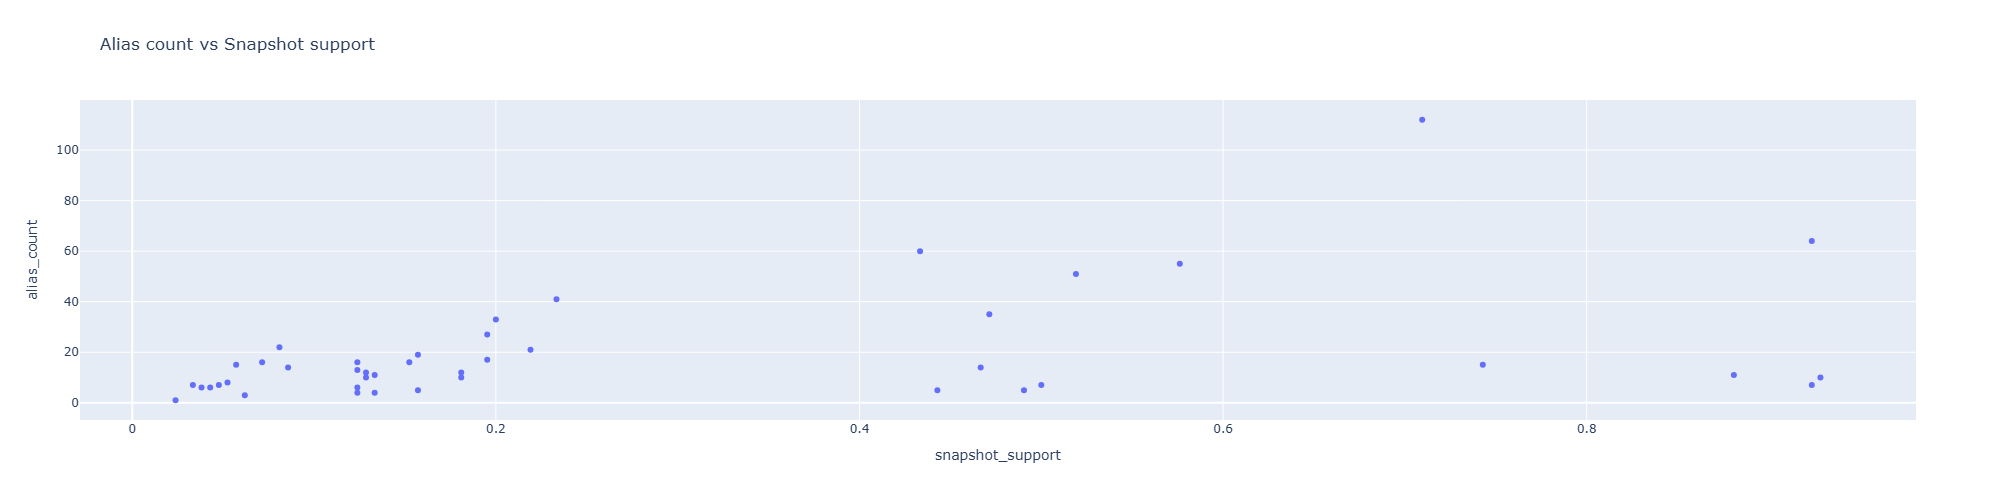

In [13]:
px.scatter(
    agg6.reset_index(),
    x="snapshot_support",
    y="alias_count",
    hover_name="canonical_name",
    title="Alias count vs Snapshot support",
    width=800,
    height=500,
)

## Ontology compression

In [14]:
agg7 = df.groupby("canonical_name").agg(
    snapshot_count=("snapshot_id", "nunique"),
    profile_count=("canonical_name", "count"),
)
agg7["compression"] = (agg7["profile_count"] - agg7["snapshot_count"]) / agg7["snapshot_count"]

agg7.sort_values("compression", ascending=False)

,snapshot_count,profile_count,compression
canonical_name,,,
not_in_ontology,149,224,0.503356
geographic_role,12,18,0.500000
indicator_name,194,291,0.500000
analysis_method,41,61,0.487805
location_type,17,25,0.470588
financial_metric,15,21,0.400000
geographic_entities,42,57,0.357143
population_group,99,134,0.353535
project_component,8,10,0.250000


In [15]:
# from pandas.io.clipboard import clipboard_set

# clipboard_set(agg6.to_markdown())